# 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the underlying patterns, distributions, relationships, and trends present in the cleaned credit risk dataset.

The objective of this analysis is to identify important characteristics of borrowers and loans, examine the distribution of credit-related variables, and investigate factors associated with loan defaults.

The analysis focuses on:

- Understanding the distribution of numerical variables
- Analyzing categorical variables
- Examining loan and borrower characteristics
- Studying the relationship between applicant characteristics and loan defaults
- Identifying correlations between numerical variables
- Detecting important risk patterns and potential anomalies

### 2.1 Import Required Libraries

The cleaned dataset is analyzed using Pandas, NumPy, Matplotlib, and Seaborn.

These libraries are used for data manipulation, statistical analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2.2 Load the Cleaned Dataset

The cleaned dataset generated during the Data Cleaning stage is loaded for exploratory analysis.

In [5]:
df = pd.read_csv("credit_risk_cleaned.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 2.3 Dataset Overview

The cleaned dataset is examined to understand its dimensions and statistical characteristics before beginning detailed analysis.

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 32416
Columns: 12


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.747008,6.354100,20.00,23.00,26.00,30.00,144.00
person_income,32416.0,66091.640826,62015.580269,4000.00,38542.00,55000.00,79218.00,6000000.00
person_emp_length,32416.0,4.768880,4.090411,0.00,2.00,4.00,7.00,123.00
loan_amnt,32416.0,9593.845632,6322.730241,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32416.0,11.014662,3.083050,5.42,8.49,10.99,13.11,23.22
loan_status,32416.0,0.218688,0.413363,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32416.0,0.170250,0.106812,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32416.0,5.811297,4.059030,2.00,3.00,4.00,8.00,30.00


### 2.4 Distribution of Numerical Variables

The distributions of numerical variables are examined to understand their central tendency, spread, skewness, and variability.

Variables such as applicant age, income, employment length, loan amount, interest rate, and credit history length provide important information about borrower and loan characteristics.

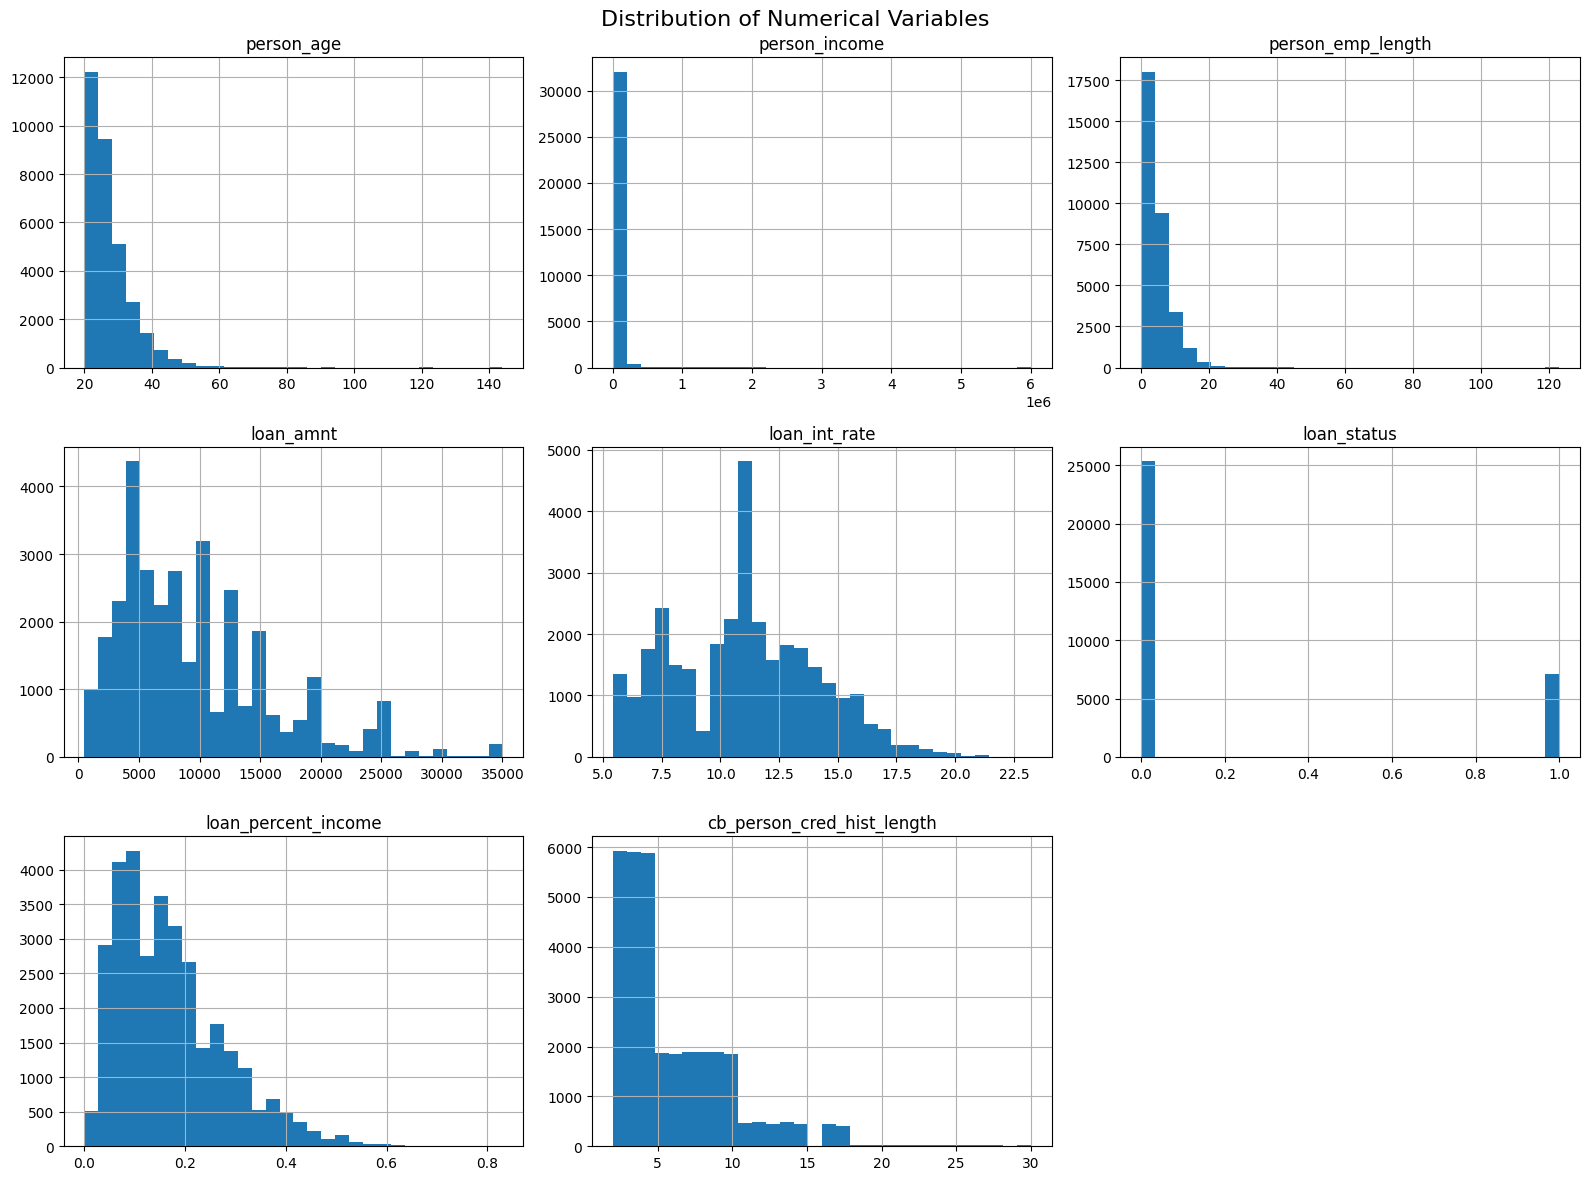

In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)
plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

### 2.5 Applicant Age Analysis

Applicant age is analyzed to understand the demographic distribution of borrowers and identify whether the dataset is concentrated within particular age groups.

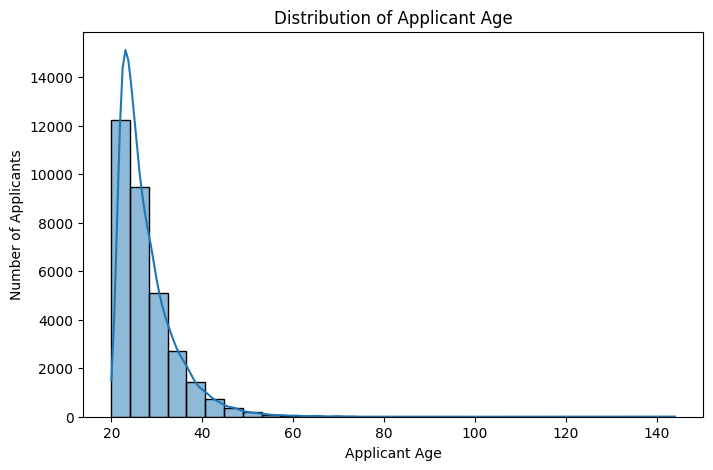

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="person_age",
    bins=30,
    kde=True
)
plt.title("Distribution of Applicant Age")
plt.xlabel("Applicant Age")
plt.ylabel("Number of Applicants")
plt.show()

### 2.6 Applicant Income Analysis

Annual income is one of the important financial characteristics of a borrower.

Its distribution is examined to understand income variability and identify highly skewed or extreme income observations.

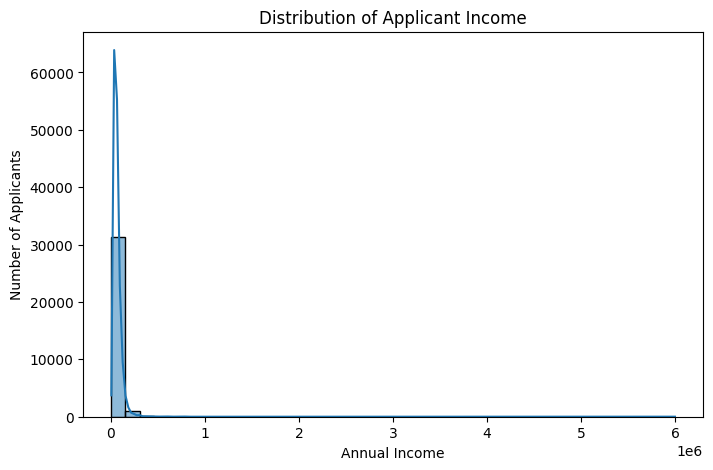

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="person_income",
    bins=40,
    kde=True
)
plt.title("Distribution of Applicant Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")
plt.show()

### 2.7 Loan Amount Analysis

The distribution of loan amounts is analyzed to understand the typical borrowing requirement and variation in requested loan values.

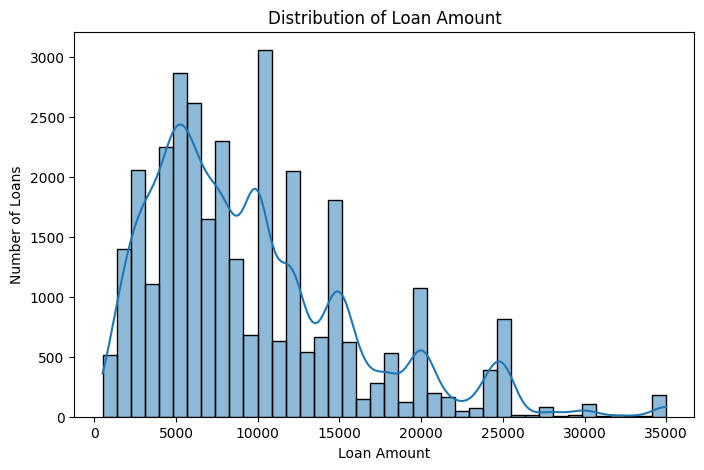

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="loan_amnt",
    bins=40,
    kde=True
)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.show()

### 2.8 Categorical Variable Analysis

Categorical variables are analyzed to understand the composition of the dataset across borrower characteristics and loan categories.

The analysis includes home ownership, loan intent, loan grade, and previous default history.

In [12]:
categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


person_home_ownership
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

loan_grade
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


### 2.9 Home Ownership Analysis

The distribution of borrowers across different home ownership categories is examined to understand the composition of the applicant population.

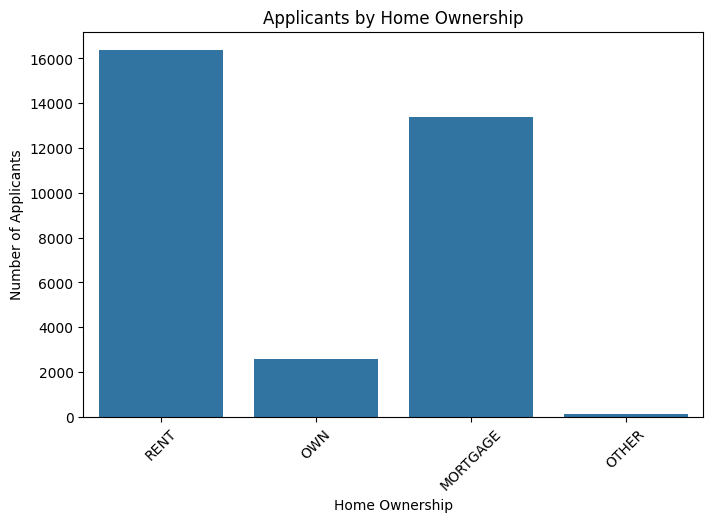

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="person_home_ownership"
)
plt.title("Applicants by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.show()

### 2.10 Loan Intent Analysis

Loan intent represents the primary purpose for which applicants seek credit.

Analyzing loan intent helps identify which purposes account for the largest share of loan applications.

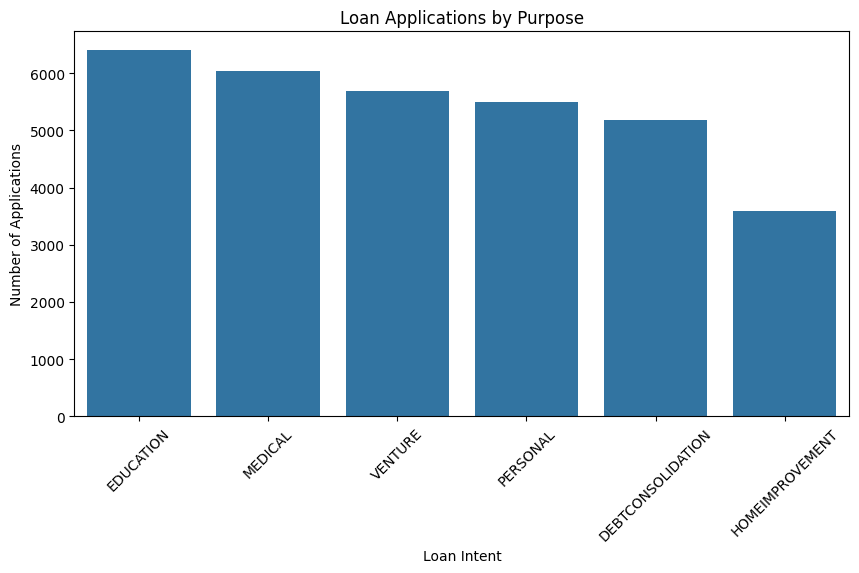

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="loan_intent",
    order=df["loan_intent"].value_counts().index
)

plt.title("Loan Applications by Purpose")
plt.xlabel("Loan Intent")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.show()

### 2.11 Loan Grade Analysis

Loan grades provide an indication of the credit quality associated with individual loans.

The distribution of loan grades is examined to understand how the dataset is distributed across different credit-risk categories.

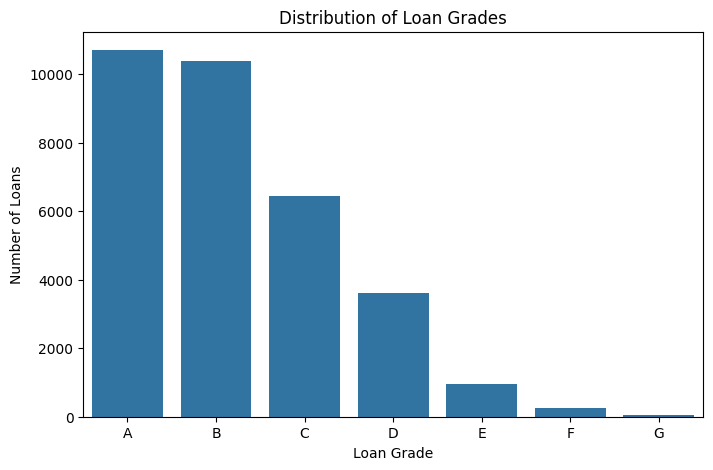

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="loan_grade",
    order=sorted(df["loan_grade"].unique())
)

plt.title("Distribution of Loan Grades")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")
plt.show()

### 2.12 Loan Default Analysis

The `loan_status` variable represents the outcome of a loan.

The distribution of default and non-default loans is examined to understand the target variable and identify potential class imbalance before developing machine learning models.

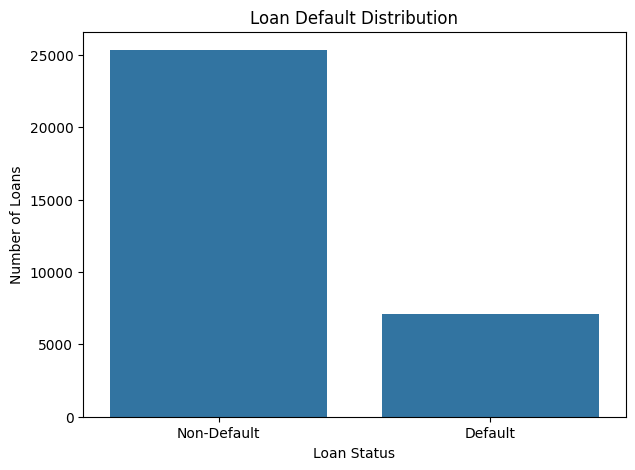

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks([0, 1], ["Non-Default", "Default"])

plt.show()

In [17]:
default_distribution = (
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
default_distribution

,proportion
loan_status,
0,78.13
1,21.87


### 2.13 Default Rate by Loan Grade

Loan default rates are calculated across different loan grades.

This analysis helps determine whether default rates vary across credit-quality categories.

In [19]:
default_by_grade = (df.groupby("loan_grade")["loan_status"].mean().mul(100).sort_index())
default_by_grade

,loan_status
loan_grade,
A,9.959824
B,16.318475
C,20.751786
D,59.060773
E,64.485981
F,70.539419
G,98.437500


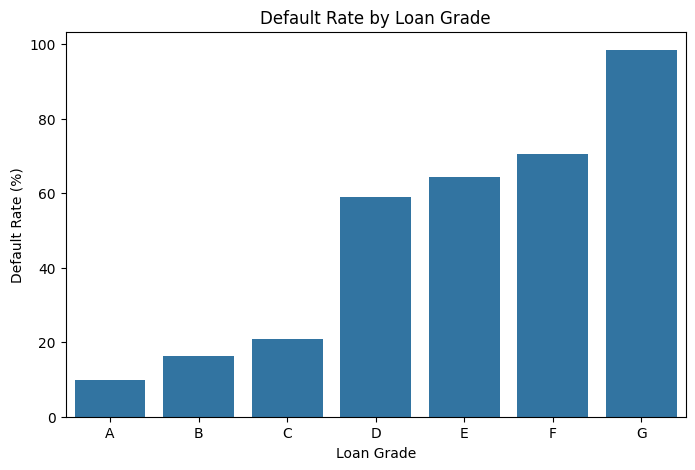

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=default_by_grade.index,
    y=default_by_grade.values
)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.show()

### 2.14 Default Rate by Loan Purpose

Default rates are compared across different loan purposes.

This helps identify whether certain loan intents have different observed default rates within the dataset.

In [21]:
default_by_intent = (df.groupby("loan_intent")["loan_status"].mean().mul(100).sort_values(ascending=False))
default_by_intent

,loan_status
loan_intent,
DEBTCONSOLIDATION,28.676045
MEDICAL,26.762661
HOMEIMPROVEMENT,26.154702
PERSONAL,19.898145
EDUCATION,17.251599
VENTURE,14.853925


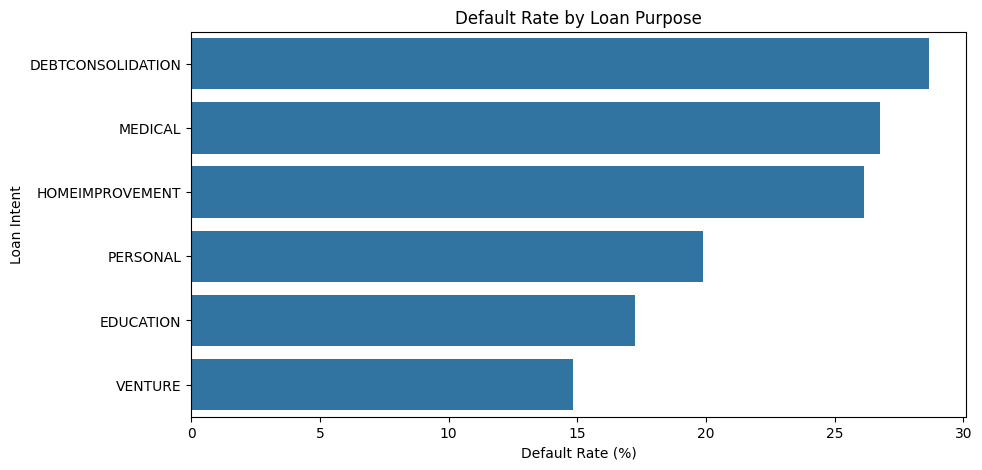

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=default_by_intent.values,
    y=default_by_intent.index
)
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Intent")
plt.show()

### 2.15 Default Rate by Home Ownership

The relationship between home ownership category and observed loan default rate is analyzed.

This provides a borrower-segment perspective on credit risk.

In [23]:
default_by_home = (df.groupby("person_home_ownership")["loan_status"].mean().mul(100).sort_values(ascending=False))
default_by_home

,loan_status
person_home_ownership,
RENT,31.609476
OTHER,31.132075
MORTGAGE,12.618745
OWN,7.491221


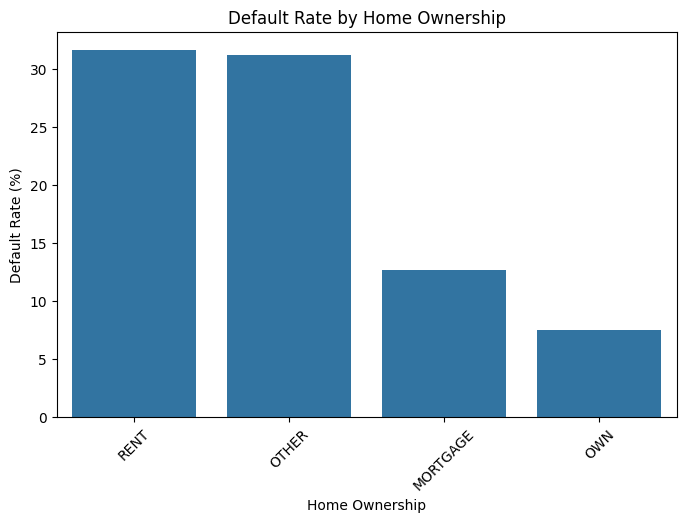

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=default_by_home.index,
    y=default_by_home.values
)
plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.show()

### 2.16 Income and Loan Amount Relationship

The relationship between applicant income and loan amount is examined using a scatter plot.

This helps determine whether higher-income applicants tend to request larger loans and highlights potential unusual observations.

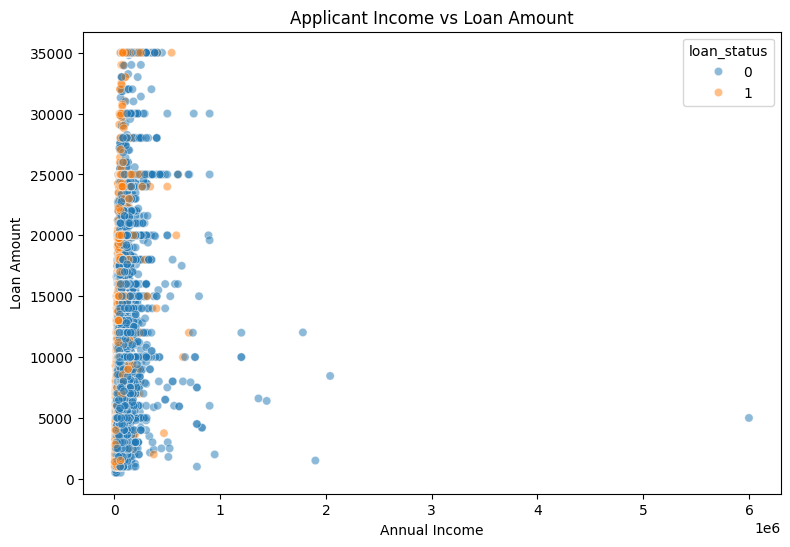

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="person_income",
    y="loan_amnt",
    hue="loan_status",
    alpha=0.5
)

plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

### 2.17 Loan-to-Income Analysis

The loan-to-income percentage represents the proportion of annual income associated with the requested loan.

A higher loan-to-income ratio may indicate a greater financial burden relative to the applicant's income.

The distribution is therefore examined as an important credit-risk characteristic.

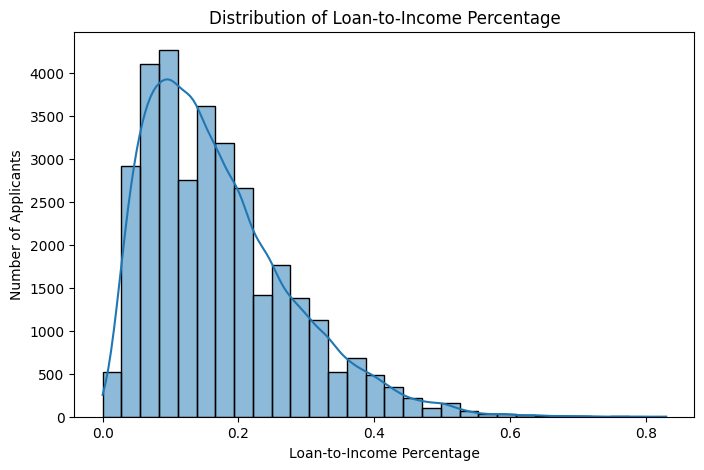

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="loan_percent_income",
    bins=30,
    kde=True
)

plt.title("Distribution of Loan-to-Income Percentage")
plt.xlabel("Loan-to-Income Percentage")
plt.ylabel("Number of Applicants")
plt.show()

### 2.18 Loan-to-Income Ratio and Default

The loan-to-income ratio is compared between default and non-default loans to identify differences in borrowing burden across loan outcomes.

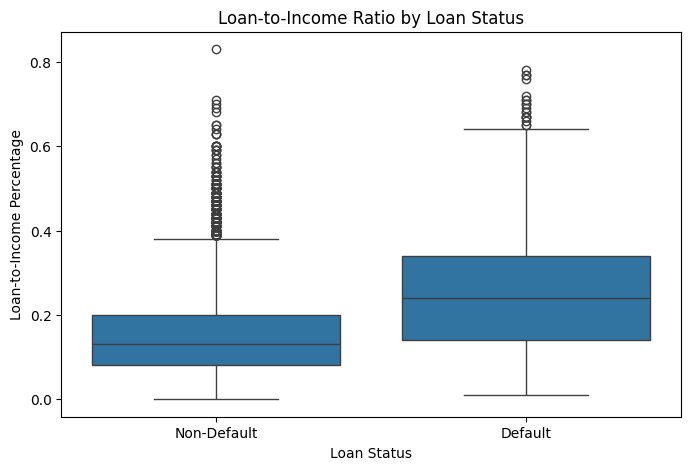

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_percent_income"
)

plt.title("Loan-to-Income Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan-to-Income Percentage")
plt.xticks([0, 1], ["Non-Default", "Default"])

plt.show()

### 2.19 Interest Rate and Default

Interest rates are compared across default and non-default loans.

The analysis helps identify whether differences in interest rates are associated with different observed loan outcomes in the dataset.

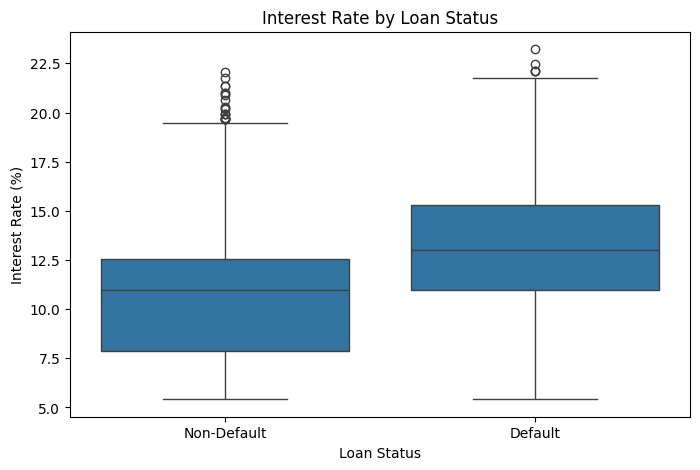

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_int_rate"
)

plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")
plt.xticks([0, 1], ["Non-Default", "Default"])

plt.show()

### 2.20 Previous Default History

The historical default indicator is analyzed to understand whether applicants with a recorded previous default have different observed loan outcomes in the current dataset.

In [29]:
previous_default = pd.crosstab(df["cb_person_default_on_file"],df["loan_status"],normalize="index") * 100
previous_default

loan_status,0,1
cb_person_default_on_file,,
N,81.567114,18.432886
Y,62.129145,37.870855


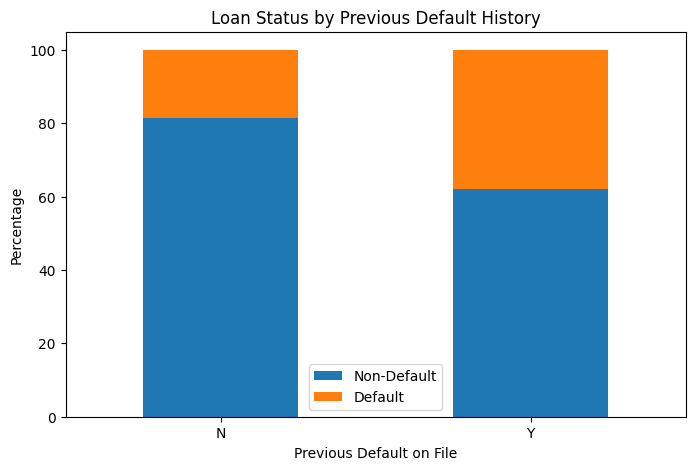

In [30]:
previous_default.plot(kind="bar",stacked=True,figsize=(8, 5))
plt.title("Loan Status by Previous Default History")
plt.xlabel("Previous Default on File")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Non-Default", "Default"])
plt.show()

### 2.21 Correlation Analysis

Correlation analysis is performed to identify relationships between numerical variables.

A correlation coefficient closer to +1 indicates a strong positive relationship, while a coefficient closer to -1 indicates a strong negative relationship.

Correlation does not imply causation, but it can help identify variables that may be useful for further analysis and predictive modeling.

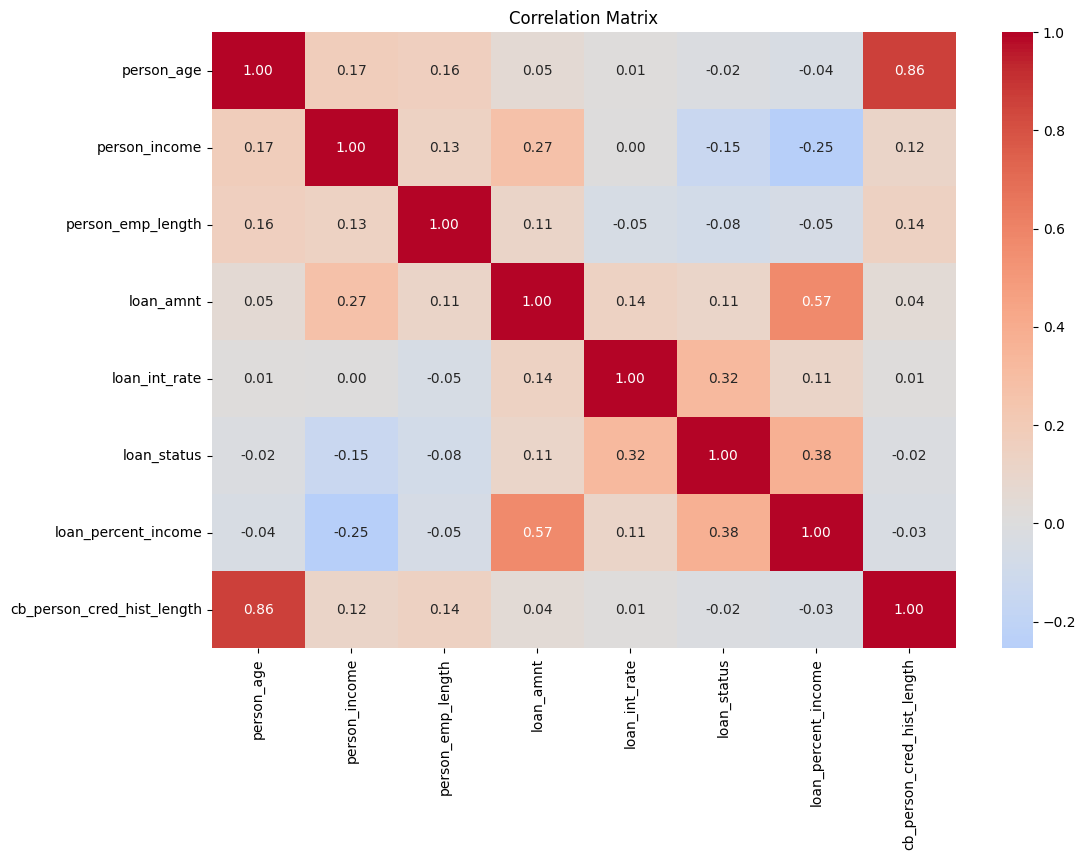

In [31]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

### 2.22 Correlation with Loan Status

The correlations between numerical variables and `loan_status` are examined to identify variables that show stronger statistical relationships with the target variable.

These relationships will be investigated further during credit-risk analysis and machine learning.

In [32]:
target_correlation = (df.select_dtypes(include=np.number).corr()["loan_status"].sort_values(ascending=False))
target_correlation

,loan_status
loan_status,1.000000
loan_percent_income,0.379697
loan_int_rate,0.320081
loan_amnt,0.105736
cb_person_cred_hist_length,-0.016498
person_age,-0.022698
person_emp_length,-0.082517
person_income,-0.145005


### 2.23 Key Exploratory Findings

The following analysis summarizes the major patterns identified during EDA.

The findings focus on borrower characteristics, loan characteristics, default patterns, and relationships between financial variables.

In [33]:
print("Total loan applications:", len(df))

print("\nDefault rate:")
print(round(df["loan_status"].mean() * 100, 2), "%")

print("\nMost common loan intent:")
print(df["loan_intent"].mode()[0])

print("\nMost common home ownership:")
print(df["person_home_ownership"].mode()[0])

print("\nMost common loan grade:")
print(df["loan_grade"].mode()[0])

print("\nAverage annual income:")
print(round(df["person_income"].mean(), 2))

print("\nAverage loan amount:")
print(round(df["loan_amnt"].mean(), 2))

print("\nAverage interest rate:")
print(round(df["loan_int_rate"].mean(), 2))

Total loan applications: 32416

Default rate:
21.87 %

Most common loan intent:
EDUCATION

Most common home ownership:
RENT

Most common loan grade:
A

Average annual income:
66091.64

Average loan amount:
9593.85

Average interest rate:
11.01


# Conclusion

- Exploratory Data Analysis provided an overview of borrower characteristics, loan attributes, and credit-risk patterns within the cleaned dataset.
- Numerical variables such as income, loan amount, interest rate, and loan-to-income percentage exhibited varying distributions and levels of variability.
- Categorical analysis revealed differences in the composition of borrowers across home ownership, loan purpose, loan grade, and previous default history.
- The distribution of `loan_status` was examined to understand the proportion of default and non-default loans and identify potential class imbalance.
- Default rates were compared across loan grades, loan purposes, and borrower segments to identify variations in observed credit-risk patterns.
- Relationships between income, loan amount, loan-to-income percentage, interest rate, and loan outcomes were investigated using statistical summaries and visualizations.
- Correlation analysis helped identify relationships among numerical variables and provided potential inputs for subsequent risk analysis and predictive modeling.
- The insights obtained from EDA establish a foundation for deeper Credit Risk Analysis, Data Quality Assessment, SQL analysis, and Machine Learning.